# Exploratory Data Analysis (EDA)

This notebook provides a reusable starting point for exploratory data analysis in this project.

**Default dataset:** `../data/clean/EnrollmentsAUS_category_with_numeric_key.csv`

> If you want to explore a different file, update `dataset_path` in the next code cell.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Resolve the dataset path robustly after moving the notebook into a subfolder
dataset_name = "EnrollmentsAUS_category_with_numeric_key.csv"
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
dataset_path = None

for root in candidate_roots:
    candidate = root / "data" / "clean" / dataset_name
    if candidate.exists():
        dataset_path = candidate
        break

if dataset_path is None:
    raise FileNotFoundError(f"Dataset not found from working directory: {Path.cwd()}")

try:
    df = pd.read_csv(dataset_path)
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding="latin-1")

print(f"Loaded {dataset_path.name}")
print(f"Resolved path: {dataset_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
df.head()

Loaded EnrollmentsAUS_category_with_numeric_key.csv
Resolved path: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\EnrollmentsAUS_category_with_numeric_key.csv
Rows: 12 | Columns: 11


,Category,2016,2017,2018,2019,2020,2021,2022,2023,2024,CategoryKey
0,Natural & Physical Science,119102,124209,129609,134334,136733,139629,134424,132406,134511,1
1,Information Technology,66355,80090,99986,116623,120916,116296,119278,143253,164464,2
2,Engineering & Related Tech,111060,115231,119909,121980,118229,112931,109812,115197,122954,3
3,Architecture & Building,32074,35604,39459,42370,43478,43773,42327,42174,40942,4
4,Environment & Related,18537,18260,18055,18747,21916,20776,19476,19284,19376,5


## 1. Inspect Data Structure

Review column names, data types, shape, and general dataset information.

In [2]:
print("Column names:")
print(df.columns.tolist())

year_cols = [col for col in df.columns if str(col).isdigit()]
id_cols = [col for col in df.columns if col not in year_cols]

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\nDetected year columns: {year_cols}")
print(f"Identifier columns: {id_cols}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nShape: {df.shape}")
print("\nDataset info:")
df.info()

enrollment_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="Year",
    value_name="Enrollments",
)
enrollment_long["Year"] = enrollment_long["Year"].astype(int)
enrollment_long["Enrollments"] = pd.to_numeric(enrollment_long["Enrollments"], errors="coerce")

if "Category" in enrollment_long.columns:
    enrollment_long_no_total = enrollment_long[enrollment_long["Category"] != "Total"].copy()
else:
    enrollment_long_no_total = enrollment_long.copy()

print("\nLong-format preview:")
display(enrollment_long.head())

Column names:
['Category', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'CategoryKey']

Detected year columns: ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Identifier columns: ['Category', 'CategoryKey']

Data types:


,dtype
Category,str
2016,int64
2017,int64
2018,int64
2019,int64
2020,int64
2021,int64
2022,int64
2023,int64
2024,int64



Shape: (12, 11)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Category     12 non-null     str  
 1   2016         12 non-null     int64
 2   2017         12 non-null     int64
 3   2018         12 non-null     int64
 4   2019         12 non-null     int64
 5   2020         12 non-null     int64
 6   2021         12 non-null     int64
 7   2022         12 non-null     int64
 8   2023         12 non-null     int64
 9   2024         12 non-null     int64
 10  CategoryKey  12 non-null     int64
dtypes: int64(10), str(1)
memory usage: 1.2 KB

Long-format preview:


,Category,CategoryKey,Year,Enrollments
0,Natural & Physical Science,1,2016,119102
1,Information Technology,2,2016,66355
2,Engineering & Related Tech,3,2016,111060
3,Architecture & Building,4,2016,32074
4,Environment & Related,5,2016,18537


## 2. Clean Missing Values and Duplicates

Check for null values and duplicate rows, then create a lightly cleaned copy of the dataset.

In [3]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
display(missing_summary.to_frame("missing_count") if not missing_summary.empty else pd.DataFrame({"message": ["No missing values found"]}))

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
print(f"Shape after dropping duplicates: {df_clean.shape}")

Missing values by column:


,message
0,No missing values found


Duplicate rows: 0
Shape after dropping duplicates: (12, 11)


## 3. Compute Summary Statistics

Generate descriptive statistics for both numeric and categorical columns.

In [4]:
df_clean_no_total = df_clean[df_clean["Category"] != "Total"].copy() if "Category" in df_clean.columns else df_clean.copy()

numeric_cols = year_cols + (["CategoryKey"] if "CategoryKey" in df_clean.columns else [])
categorical_cols = ["Category"] if "Category" in df_clean.columns else []

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

if year_cols:
    print("\nSummary statistics by year:")
    display(df_clean_no_total[year_cols].describe().T)

    year_totals = pd.DataFrame({
        "Total Enrollments": df_clean[year_cols].sum(),
        "Average per Category": df_clean_no_total[year_cols].mean(),
    })
    display(year_totals)
else:
    print("No year columns detected for summary statistics.")

if "Category" in df_clean.columns and year_cols:
    category_change = df_clean_no_total[["Category", year_cols[0], year_cols[-1]]].copy()
    category_change["Absolute Change"] = category_change[year_cols[-1]] - category_change[year_cols[0]]
    category_change["Percent Change"] = (category_change["Absolute Change"] / category_change[year_cols[0]] * 100).round(2)
    display(category_change.sort_values("Absolute Change", ascending=False))

Numeric columns (10): ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'CategoryKey']
Categorical columns (1): ['Category']

Summary statistics by year:


,count,mean,std,min,25%,50%,75%,max
2016,11.0,139313.818182,119680.013640,18537.0,50542.0,111060.0,181655.0,380800.0
2017,11.0,144671.545455,122611.139513,18260.0,57847.0,115231.0,187900.5,389836.0
2018,11.0,149355.363636,123915.084208,18055.0,67827.0,119909.0,192966.5,396813.0
2019,11.0,153740.181818,124954.971645,18747.0,69924.0,121980.0,199960.0,399609.0
2020,11.0,154976.181818,124004.013643,21916.0,70611.5,120916.0,207161.5,380050.0
2021,11.0,153318.272727,122675.016167,20676.0,71150.5,116296.0,215178.0,352882.0
2022,11.0,148402.363636,117871.741851,19476.0,67869.5,119278.0,208491.5,340454.0
2023,11.0,152557.454545,119196.659193,19284.0,67335.0,132406.0,213156.5,360236.0
2024,11.0,159470.272727,121735.158919,19376.0,68542.0,134511.0,229981.0,368989.0


,Total Enrollments,Average per Category
2016,2989661,139313.818182
2017,3104770,144671.545455
2018,3205429,149355.363636
2019,3300940,153740.181818
2020,3327605,154976.181818
2021,3289074,153318.272727
2022,3183837,148402.363636
2023,3278695,152557.454545
2024,3430250,159470.272727


,Category,2016,2024,Absolute Change,Percent Change
1,Information Technology,66355,164464,98109,147.85
5,Health,235033,295498,60465,25.73
6,Education,128277,153177,24900,19.41
8,Society & Culture,312569,329590,17021,5.45
0,Natural & Physical Science,119102,134511,15409,12.94
2,Engineering & Related Tech,111060,122954,11894,10.71
3,Architecture & Building,32074,40942,8868,27.65
9,Creative Arts,93916,96142,2226,2.37
4,Environment & Related,18537,19376,839,4.53
10,Others,34729,28530,-6199,-17.85


## 4. Visualize Enrollment Trends

Plot how enrollments change over time, compare categories, include a Tukey box plot for each area of study, and highlight the latest year.

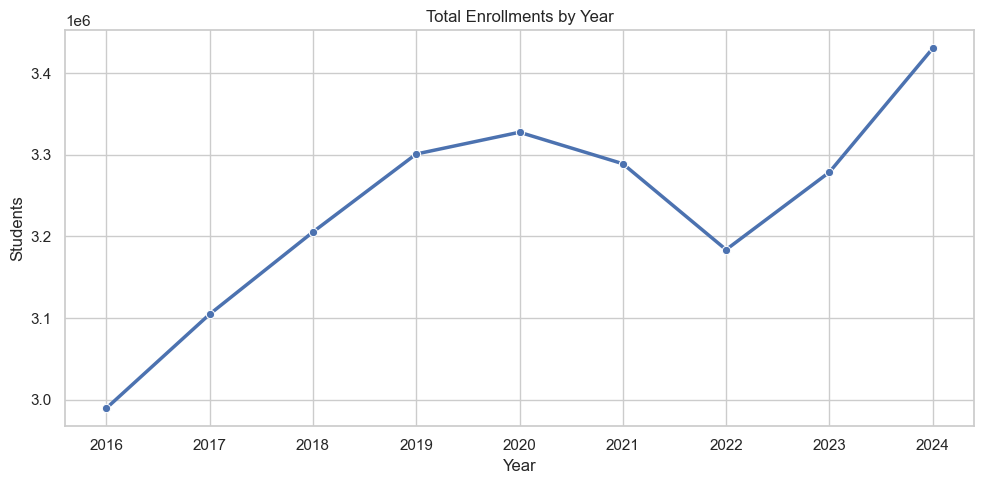

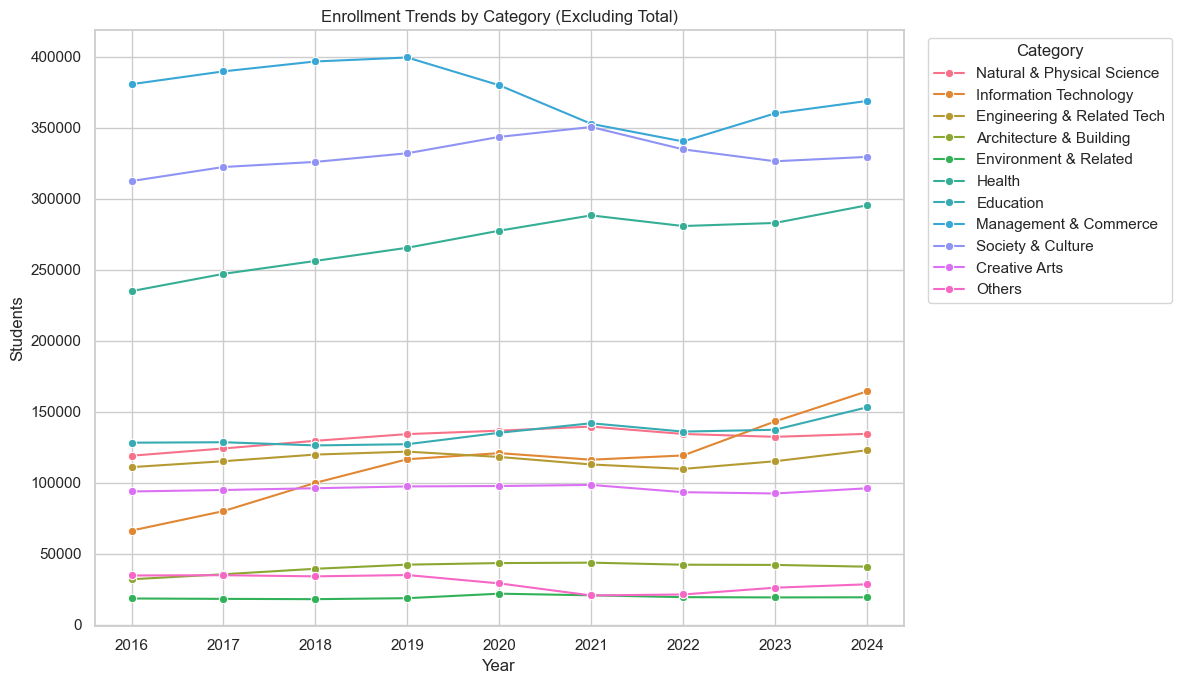

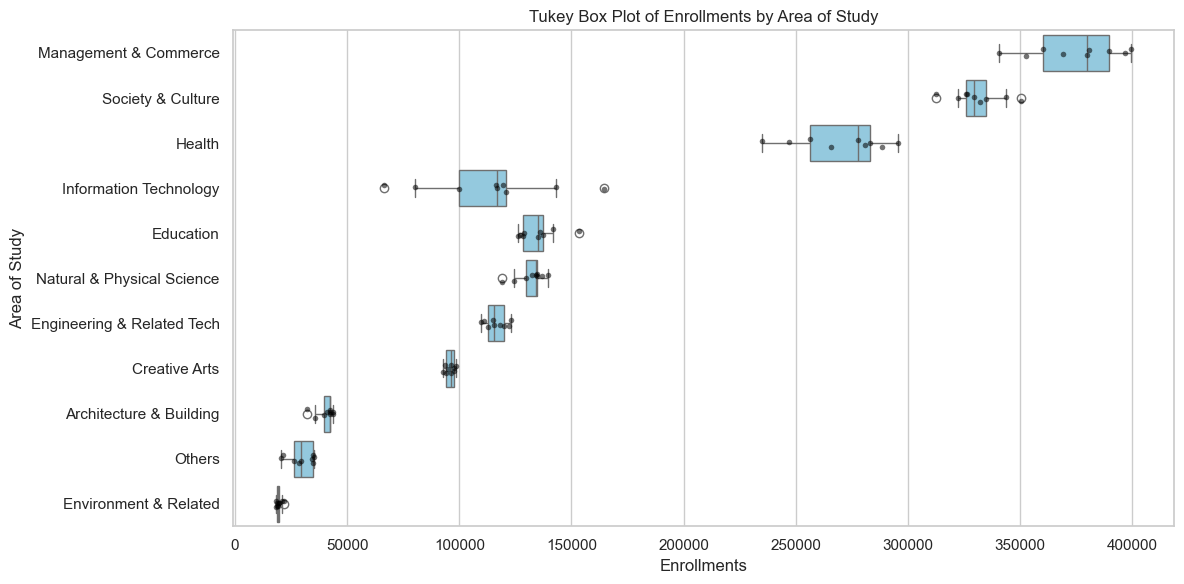

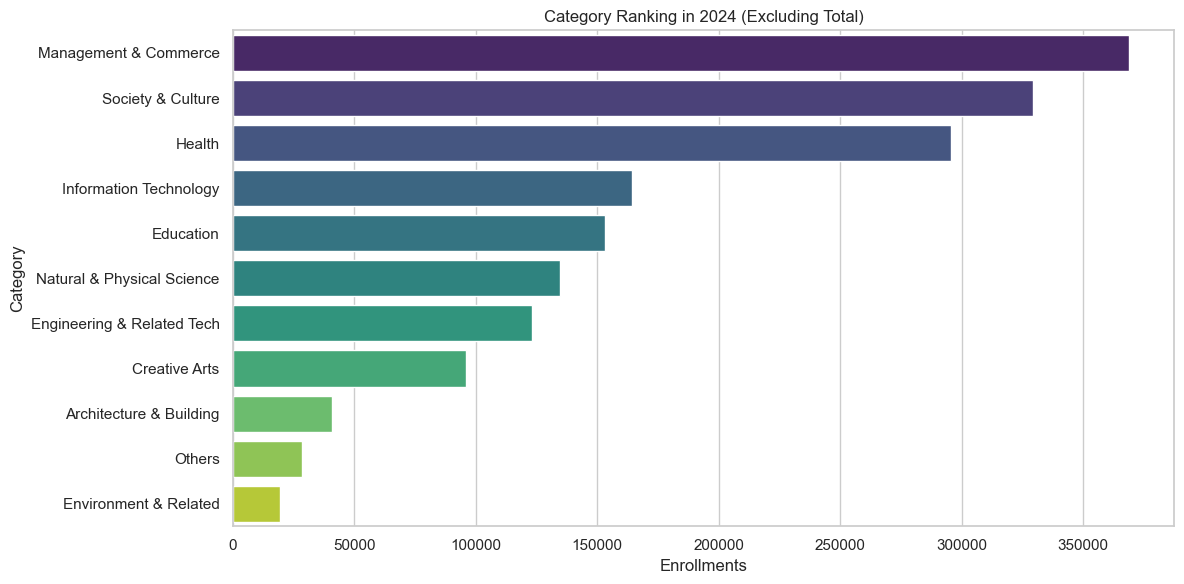

In [5]:
if year_cols:
    yearly_totals = enrollment_long.groupby("Year", as_index=False)["Enrollments"].sum()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=yearly_totals, x="Year", y="Enrollments", marker="o", linewidth=2.5)
    plt.title("Total Enrollments by Year")
    plt.ylabel("Students")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=enrollment_long_no_total, x="Year", y="Enrollments", hue="Category", marker="o")
    plt.title("Enrollment Trends by Category (Excluding Total)")
    plt.ylabel("Students")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    latest_year = max(year_cols, key=int)
    latest_ranking = df_clean_no_total[["Category", latest_year]].sort_values(latest_year, ascending=False)
    category_order = latest_ranking["Category"].tolist()

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=enrollment_long_no_total,
        x="Enrollments",
        y="Category",
        order=category_order,
        whis=1.5,
        color="skyblue",
    )
    sns.stripplot(
        data=enrollment_long_no_total,
        x="Enrollments",
        y="Category",
        order=category_order,
        color="black",
        alpha=0.55,
        size=4,
    )
    plt.title("Tukey Box Plot of Enrollments by Area of Study")
    plt.xlabel("Enrollments")
    plt.ylabel("Area of Study")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=latest_ranking, x=latest_year, y="Category", hue="Category", palette="viridis", legend=False)
    plt.title(f"Category Ranking in {latest_year} (Excluding Total)")
    plt.xlabel("Enrollments")
    plt.tight_layout()
    plt.show()
else:
    print("No year columns detected for trend visualizations.")

## 5. Explore Correlations Across Years

Check how yearly enrollment patterns move together across the time series.

,2016,2017,2018,2019,2020,2021,2022,2023,2024
2016,1.000000,0.999945,0.999689,0.999334,0.998912,0.998165,0.997969,0.997719,0.996872
2017,0.999945,1.000000,0.999891,0.999655,0.999308,0.998603,0.998462,0.998317,0.997557
2018,0.999689,0.999891,1.000000,0.999929,0.999630,0.998911,0.998853,0.998919,0.998301
2019,0.999334,0.999655,0.999929,1.000000,0.999807,0.999147,0.999152,0.999340,0.998847
2020,0.998912,0.999308,0.999630,0.999807,1.000000,0.999754,0.999760,0.999740,0.999317
2021,0.998165,0.998603,0.998911,0.999147,0.999754,1.000000,0.999980,0.999633,0.999221
2022,0.997969,0.998462,0.998853,0.999152,0.999760,0.999980,1.000000,0.999764,0.999426
2023,0.997719,0.998317,0.998919,0.999340,0.999740,0.999633,0.999764,1.000000,0.999879
2024,0.996872,0.997557,0.998301,0.998847,0.999317,0.999221,0.999426,0.999879,1.000000


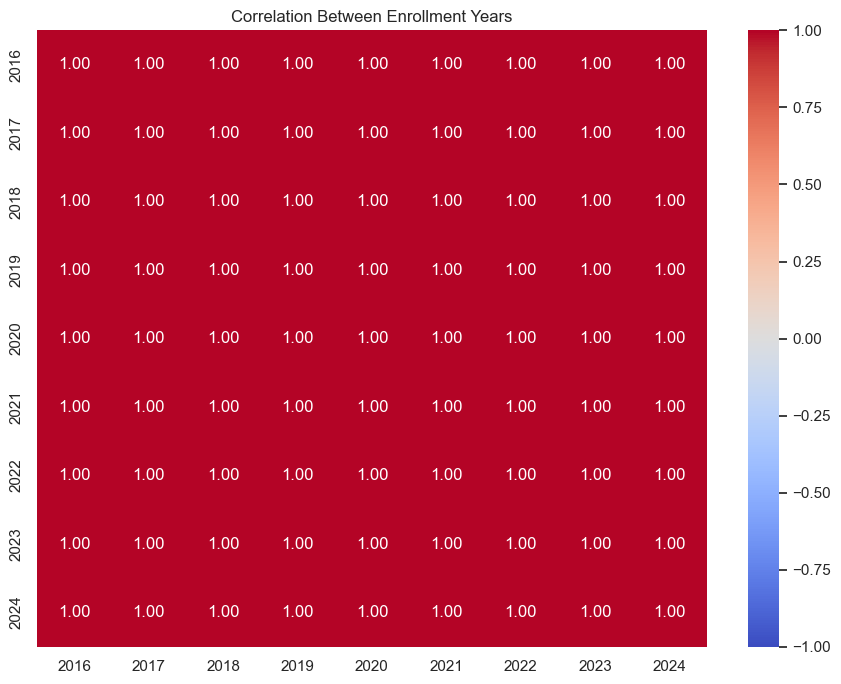

In [6]:
if len(year_cols) >= 2:
    corr_matrix = df_clean[year_cols].corr()
    display(corr_matrix)

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Between Enrollment Years")
    plt.tight_layout()
    plt.show()
else:
    print("At least two year columns are needed to compute correlations.")

## 6. Identify Fast-Growing and Unusual Categories

Measure category growth from the first to the last year and flag unusually large changes.

,Category,2016,2024,Absolute Change,Percent Change,Potential Outlier
1,Information Technology,66355,164464,98109,147.85,True
5,Health,235033,295498,60465,25.73,True
6,Education,128277,153177,24900,19.41,False
8,Society & Culture,312569,329590,17021,5.45,False
0,Natural & Physical Science,119102,134511,15409,12.94,False
2,Engineering & Related Tech,111060,122954,11894,10.71,False
3,Architecture & Building,32074,40942,8868,27.65,False
9,Creative Arts,93916,96142,2226,2.37,False
4,Environment & Related,18537,19376,839,4.53,False
10,Others,34729,28530,-6199,-17.85,False


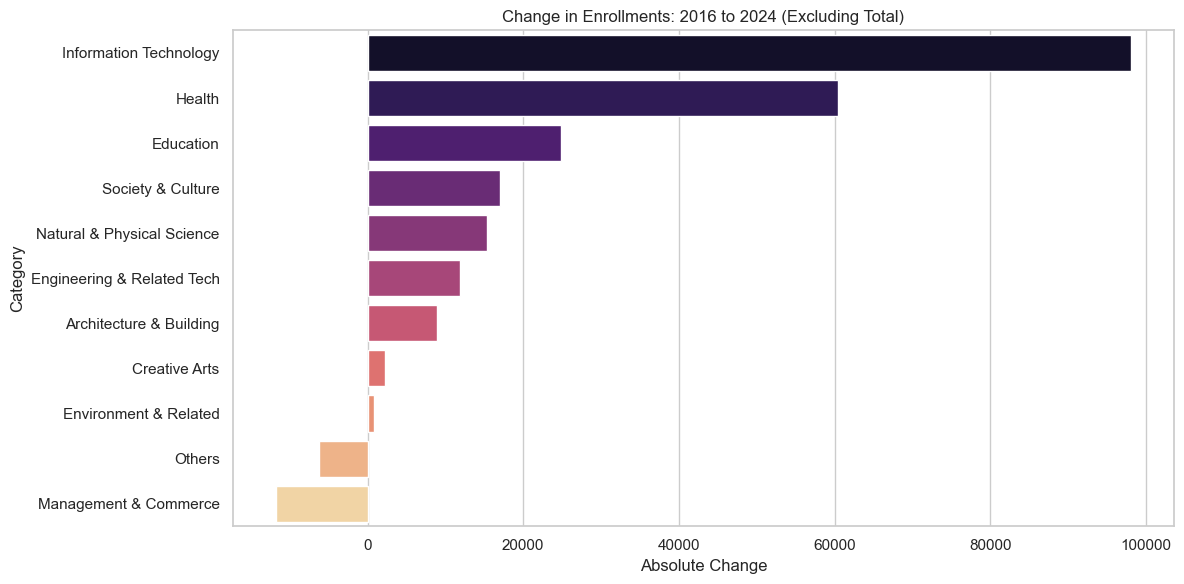

Outlier bounds for absolute change: lower=-27609.50, upper=50102.50


,Category,2016,2024,Absolute Change,Percent Change,Potential Outlier
1,Information Technology,66355,164464,98109,147.85,True
5,Health,235033,295498,60465,25.73,True


In [7]:
if "Category" in df_clean.columns and len(year_cols) >= 2:
    growth_df = df_clean_no_total[["Category", year_cols[0], year_cols[-1]]].copy()
    growth_df["Absolute Change"] = growth_df[year_cols[-1]] - growth_df[year_cols[0]]
    growth_df["Percent Change"] = (growth_df["Absolute Change"] / growth_df[year_cols[0]] * 100).round(2)

    q1 = growth_df["Absolute Change"].quantile(0.25)
    q3 = growth_df["Absolute Change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    growth_df["Potential Outlier"] = ~growth_df["Absolute Change"].between(lower, upper, inclusive="both")

    display(growth_df.sort_values("Absolute Change", ascending=False))

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=growth_df.sort_values("Absolute Change", ascending=False),
        x="Absolute Change",
        y="Category",
        hue="Category",
        palette="magma",
        legend=False,
    )
    plt.title(f"Change in Enrollments: {year_cols[0]} to {year_cols[-1]} (Excluding Total)")
    plt.tight_layout()
    plt.show()

    print(f"Outlier bounds for absolute change: lower={lower:.2f}, upper={upper:.2f}")
    display(growth_df[growth_df["Potential Outlier"]])
else:
    print("Category and at least two year columns are required for growth analysis.")

## 7. Separate Tukey Box Plots by Area of Study

This section shows one independent Tukey box plot for each area of study, using only that category's yearly enrollments.

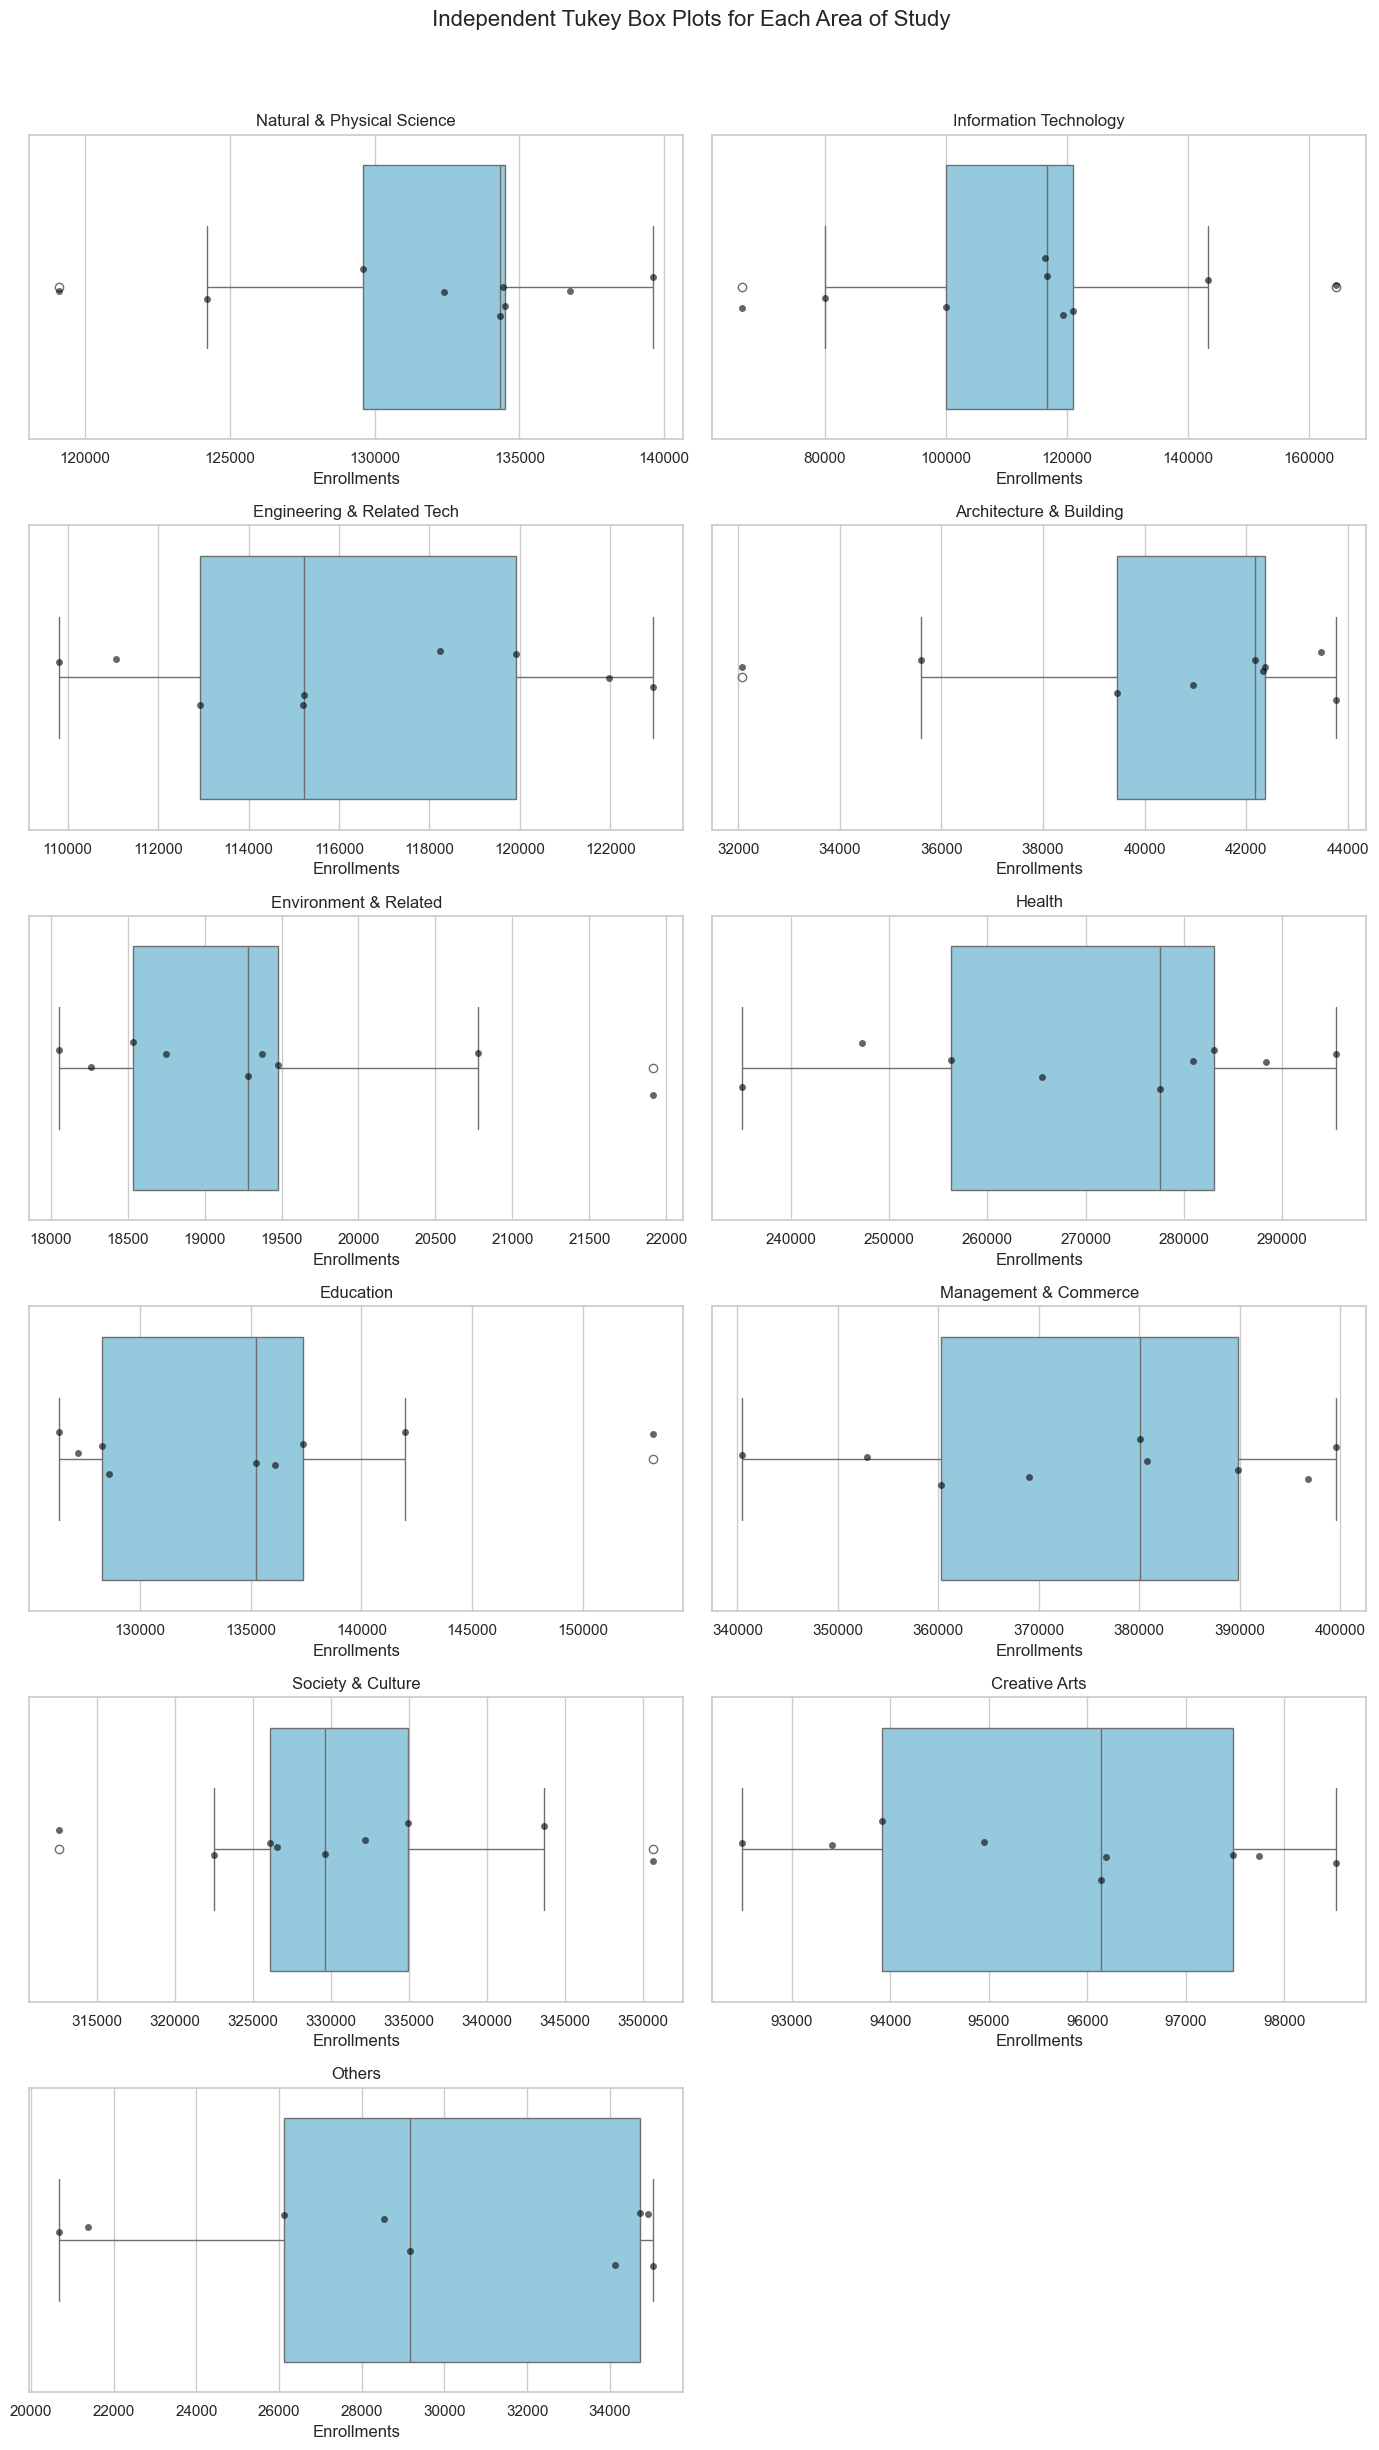

In [8]:
if "Category" in enrollment_long_no_total.columns:
    categories = enrollment_long_no_total["Category"].dropna().unique().tolist()
    n_cols = 2
    n_rows = (len(categories) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, category in zip(axes, categories):
        cat_values = enrollment_long_no_total.loc[
            enrollment_long_no_total["Category"] == category, "Enrollments"
        ].dropna()

        sns.boxplot(x=cat_values, ax=ax, whis=1.5, color="skyblue")
        sns.stripplot(x=cat_values, ax=ax, color="black", alpha=0.6, size=5)
        ax.set_title(category)
        ax.set_xlabel("Enrollments")
        ax.set_yticks([])

    for ax in axes[len(categories):]:
        ax.set_visible(False)

    plt.suptitle("Independent Tukey Box Plots for Each Area of Study", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Category data is required to create separate Tukey box plots.")

## 8. Additional Statistical Checks

This section tests for correlation, nonlinearity, heterogeneity, and subgroup differences in Australian enrollments.

In [9]:
# Prepare analysis data for additional checks
try:
    from scipy import stats
except ImportError:
    stats = None
    print('scipy is not installed; inferential tests will be skipped.')

analysis_enrollment_df = enrollment_long_no_total.copy()
analysis_enrollment_df = analysis_enrollment_df.dropna(subset=['Year', 'Enrollments'])
analysis_enrollment_df['Year'] = pd.to_numeric(analysis_enrollment_df['Year'], errors='coerce')
analysis_enrollment_df['Enrollments'] = pd.to_numeric(analysis_enrollment_df['Enrollments'], errors='coerce')
analysis_enrollment_df = analysis_enrollment_df.dropna(subset=['Year', 'Enrollments'])

yearly_enrollment = analysis_enrollment_df.groupby('Year', as_index=False)['Enrollments'].sum().sort_values('Year')
category_year_enrollment = analysis_enrollment_df.groupby(['Year', 'Category'], as_index=False)['Enrollments'].sum().sort_values(['Year', 'Category'])

display(category_year_enrollment.head())
print(f'Rows available for checks: {len(category_year_enrollment)}')

,Year,Category,Enrollments
0,2016,Architecture & Building,32074
1,2016,Creative Arts,93916
2,2016,Education,128277
3,2016,Engineering & Related Tech,111060
4,2016,Environment & Related,18537


Rows available for checks: 99


In [10]:
# Correlation checks
pearson_year_enrollment = yearly_enrollment[['Year', 'Enrollments']].corr(method='pearson').iloc[0, 1]
spearman_year_enrollment = yearly_enrollment[['Year', 'Enrollments']].corr(method='spearman').iloc[0, 1]

print(f'Pearson correlation between Year and total Enrollments: {pearson_year_enrollment:.4f}')
print(f'Spearman correlation between Year and total Enrollments: {spearman_year_enrollment:.4f}')

category_corr = (
    category_year_enrollment.groupby('Category')
    .apply(lambda g: g['Year'].corr(g['Enrollments']) if g['Year'].nunique() > 1 else np.nan)
    .reset_index(name='Year_vs_Enrollments_corr')
    .sort_values('Year_vs_Enrollments_corr', ascending=False)
)

print('Category-level correlation between Year and Enrollments')
display(category_corr)

Pearson correlation between Year and total Enrollments: 0.7759
Spearman correlation between Year and total Enrollments: 0.6333
Category-level correlation between Year and Enrollments


,Category,Year_vs_Enrollments_corr
6,Information Technology,0.949774
5,Health,0.949269
2,Education,0.839072
0,Architecture & Building,0.719972
8,Natural & Physical Science,0.718701
10,Society & Culture,0.469865
4,Environment & Related,0.412253
3,Engineering & Related Tech,0.177156
1,Creative Arts,-0.065227
7,Management & Commerce,-0.664642


Linear fit R^2: 0.6020
Quadratic fit R^2: 0.6835
There is evidence of nonlinearity because the quadratic fit improves noticeably.


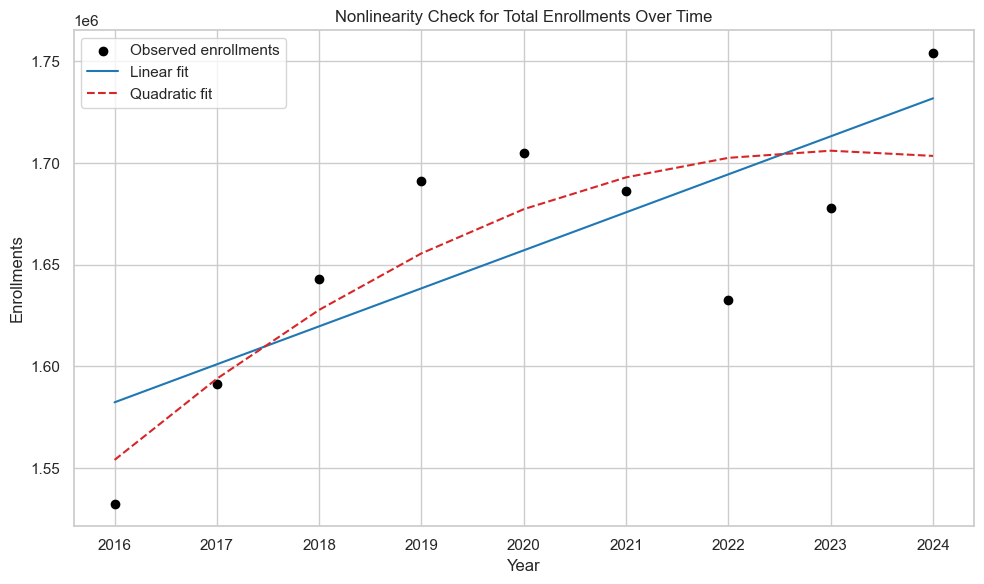

In [11]:
# Nonlinearity check: linear vs quadratic trend in total enrollments
x = yearly_enrollment['Year'].to_numpy(dtype=float)
y = yearly_enrollment['Enrollments'].to_numpy(dtype=float)

lin_coef = np.polyfit(x, y, 1)
quad_coef = np.polyfit(x, y, 2)
lin_pred = np.polyval(lin_coef, x)
quad_pred = np.polyval(quad_coef, x)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

lin_r2 = r2_score(y, lin_pred)
quad_r2 = r2_score(y, quad_pred)

print(f'Linear fit R^2: {lin_r2:.4f}')
print(f'Quadratic fit R^2: {quad_r2:.4f}')
if quad_r2 - lin_r2 > 0.02:
    print('There is evidence of nonlinearity because the quadratic fit improves noticeably.')
else:
    print('The enrollment trend appears mostly linear over time.')

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed enrollments')
plt.plot(x, lin_pred, color='tab:blue', label='Linear fit')
plt.plot(x, quad_pred, color='tab:red', linestyle='--', label='Quadratic fit')
plt.title('Nonlinearity Check for Total Enrollments Over Time')
plt.xlabel('Year')
plt.ylabel('Enrollments')
plt.legend()
plt.tight_layout()
plt.show()

Variation in enrollments by category


,mean,std,min,max,count,cv
Category,,,,,,
Information Technology,114140.111111,29804.242632,66355,164464,9,0.261120
Management & Commerce,374407.666667,20292.367327,340454,399609,9,0.054199
Health,269951.222222,20260.713060,235033,295498,9,0.075053
Society & Culture,330954.000000,11303.235610,312569,350654,9,0.034153
Education,134924.777778,8714.122672,126360,153177,9,0.064585
Natural & Physical Science,131661.888889,6424.001020,119102,139629,9,0.048792
Others,29411.666667,5761.635336,20676,35058,9,0.195896
Engineering & Related Tech,116367.000000,4697.138916,109812,122954,9,0.040365
Architecture & Building,40244.555556,3950.920592,32074,43773,9,0.098173


Levene's test for equal variances: statistic=4.9022, p-value=1.299e-05
One-way ANOVA across categories: statistic=716.4123, p-value=9.229e-80
Kruskal-Wallis test across categories: statistic=94.0232, p-value=8.501e-16
Variance differs significantly across categories, indicating heterogeneity.
There are statistically significant subgroup differences across categories.


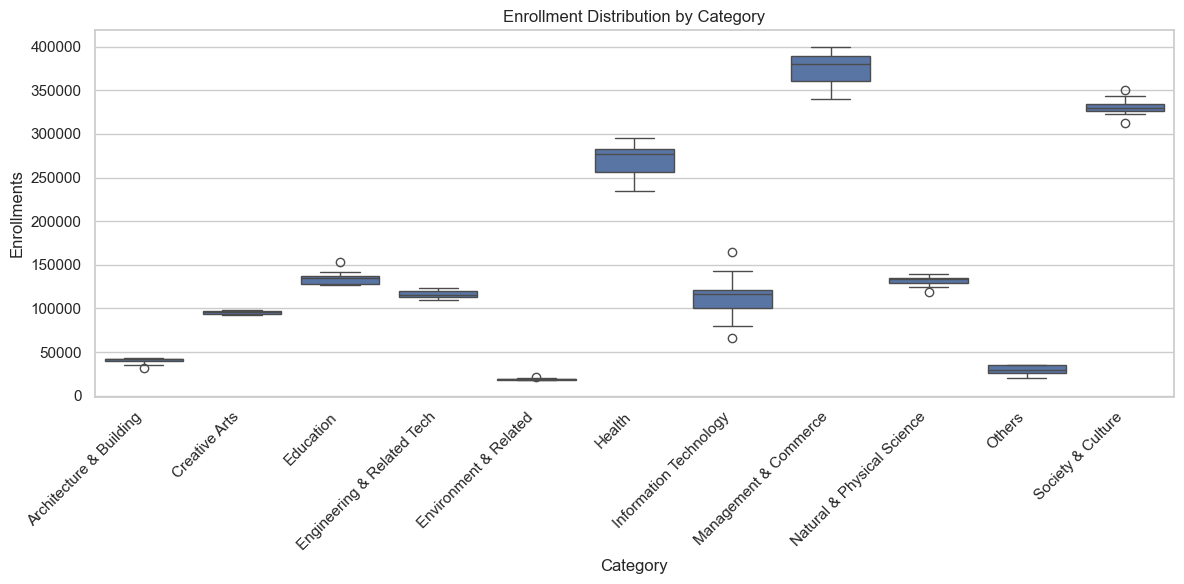

In [12]:
# Heterogeneity and subgroup difference checks
category_stats = (
    category_year_enrollment.groupby('Category')['Enrollments']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
)
category_stats['cv'] = category_stats['std'] / category_stats['mean']

print('Variation in enrollments by category')
display(category_stats)

groups = [grp['Enrollments'].values for _, grp in category_year_enrollment.groupby('Category') if len(grp) > 1]

if stats is not None and len(groups) >= 2:
    levene_stat, levene_p = stats.levene(*groups, center='median')
    anova_stat, anova_p = stats.f_oneway(*groups)
    kruskal_stat, kruskal_p = stats.kruskal(*groups)

    print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.4g}")
    print(f'One-way ANOVA across categories: statistic={anova_stat:.4f}, p-value={anova_p:.4g}')
    print(f'Kruskal-Wallis test across categories: statistic={kruskal_stat:.4f}, p-value={kruskal_p:.4g}')

    if levene_p < 0.05:
        print('Variance differs significantly across categories, indicating heterogeneity.')
    else:
        print('No strong evidence of unequal variance across categories.')

    if anova_p < 0.05 or kruskal_p < 0.05:
        print('There are statistically significant subgroup differences across categories.')
    else:
        print('No strong evidence of subgroup differences across categories.')
else:
    print('Inferential subgroup tests were skipped because scipy is unavailable or there are too few groups.')

plt.figure(figsize=(12, 6))
sns.boxplot(data=category_year_enrollment, x='Category', y='Enrollments')
plt.title('Enrollment Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Enrollments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mean enrollments: 150,645
Median enrollments: 119,909
Standard deviation: 116,929
IQR: 208,837 (Q1=42,924, Q3=251,761)
Skewness: 0.787


,Enrollments
count,99.000000
mean,150645.050505
std,116928.926671
min,18055.000000
25%,42924.000000
50%,119909.000000
75%,251761.000000
max,399609.000000


,MedianEnrollments
Category,
Management & Commerce,380050.0
Society & Culture,329590.0
Health,277590.0
Education,135250.0
Natural & Physical Science,134334.0
Information Technology,116623.0
Engineering & Related Tech,115231.0
Creative Arts,96142.0
Architecture & Building,42174.0


,Count
EnrollmentBand,
Lower band,27
Middle band,43
Upper band,11
Highest band,18


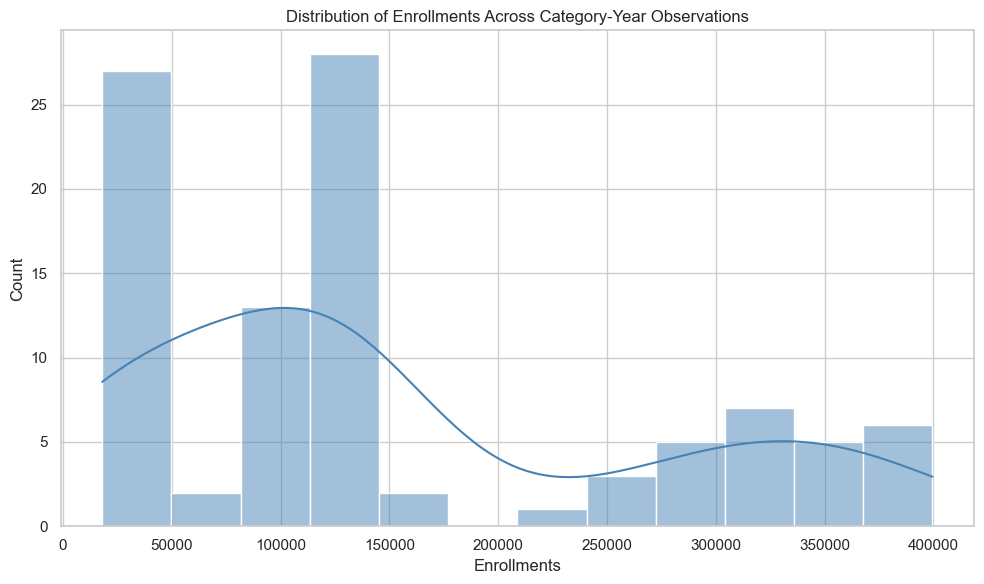

In [13]:
# Structure diagnostics: typical values, spread, skewness, and clumps
structure_df = category_year_enrollment.copy()

summary_stats = structure_df['Enrollments'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('Enrollments')
q1 = structure_df['Enrollments'].quantile(0.25)
median = structure_df['Enrollments'].median()
q3 = structure_df['Enrollments'].quantile(0.75)
iqr = q3 - q1
mean_val = structure_df['Enrollments'].mean()
std_val = structure_df['Enrollments'].std()
skewness = structure_df['Enrollments'].skew()

print(f'Mean enrollments: {mean_val:,.0f}')
print(f'Median enrollments: {median:,.0f}')
print(f'Standard deviation: {std_val:,.0f}')
print(f'IQR: {iqr:,.0f} (Q1={q1:,.0f}, Q3={q3:,.0f})')
print(f'Skewness: {skewness:.3f}')

category_medians = (
    structure_df.groupby('Category')['Enrollments']
    .median()
    .sort_values(ascending=False)
    .to_frame('MedianEnrollments')
)

structure_df['EnrollmentBand'] = pd.cut(
    structure_df['Enrollments'],
    bins=[0, 50000, 150000, 300000, np.inf],
    labels=['Lower band', 'Middle band', 'Upper band', 'Highest band'],
    include_lowest=True,
)

band_counts = structure_df['EnrollmentBand'].value_counts().sort_index().to_frame('Count')

display(summary_stats)
display(category_medians)
display(band_counts)

plt.figure(figsize=(10, 6))
sns.histplot(structure_df['Enrollments'], bins=12, kde=True, color='steelblue')
plt.title('Distribution of Enrollments Across Category-Year Observations')
plt.xlabel('Enrollments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Interpretation of Additional Checks

### Key takeaways

- **Structure of the data:** The category-year enrollment values show a **wide spread**, with a mean of about **150,645**, a median of about **119,909**, and a standard deviation of about **116,929**. The interquartile range is about **208,837**, so the middle half of observations is fairly dispersed.
- **Typical values and clumps:** Most observations fall in the **lower-to-middle enrollment range**, while a smaller group of category-year values sits much higher, especially in areas such as **Management & Commerce**, **Society & Culture**, and **Health**. This indicates visible **clumping** rather than one uniform distribution.
- **Skewness:** The distribution is **positively skewed** with skewness around **0.787**, meaning high-enrollment fields pull the upper tail to the right.
- **Trend over time:** Total enrollments show a positive relationship with time, with Pearson correlation around **0.7759** and Spearman correlation around **0.6333**. The quadratic model fits slightly better than the linear one, with $R^2 \approx 0.6835$ compared with $R^2 \approx 0.6020$, suggesting **some nonlinearity** in the growth path.
- **Heterogeneity and subgroup differences:** Levene’s test was significant, with $p \approx 1.299 \times 10^{-5}$, showing that enrollment variability is **not constant across subject areas**. ANOVA and Kruskal-Wallis were also highly significant, with $p \approx 9.229 \times 10^{-80}$ and $p \approx 8.501 \times 10^{-16}$ respectively, confirming **strong subgroup differences**.

### Overall interpretation

Australian university enrollments are not evenly distributed across disciplines. Instead, they cluster around lower and middle ranges with a smaller number of much larger categories, producing a mildly right-skewed structure. The overall trend is upward, but the size and pace of growth differ clearly across subject areas.

## Data Characteristics & First-Order Effects

**Variables:** `Category` (11 nominal FOE groups), `Year` (integer 2016–2024), `Enrollments` (headcount, ~10k–500k range). The dataset is stored in wide format (one column per year) and reshaped to long format for time-series analysis; the aggregate `Total` row is removed to prevent double-counting.

**Data cleaning:** No values were dropped due to missingness (zero missing after loading). The primary transformation — wide-to-long reshape — is lossless. Removing the `Total` row is the only structural change.

The analysis below tests whether (1) the raw enrollment distribution requires transformation and (2) the overall Year–Enrollment trend is consistent across all categories or conceals a Simpson's Paradox.

=== AUS Enrollments — Variable Summary ===
Shape (long): (99, 3)  |  Categories: 11
Year range: 2016–2024
Enrollment range: 18,055 – 399,609
Missing values: 0

Overall r(Year, Enrollments) = 0.038  (p=0.7109)
Within-category negative trends: 3/11
⚠  Simpson's Paradox: aggregate POSITIVE but some categories NEGATIVE

Skewness  raw=0.775  |  log(1+x)=-0.393


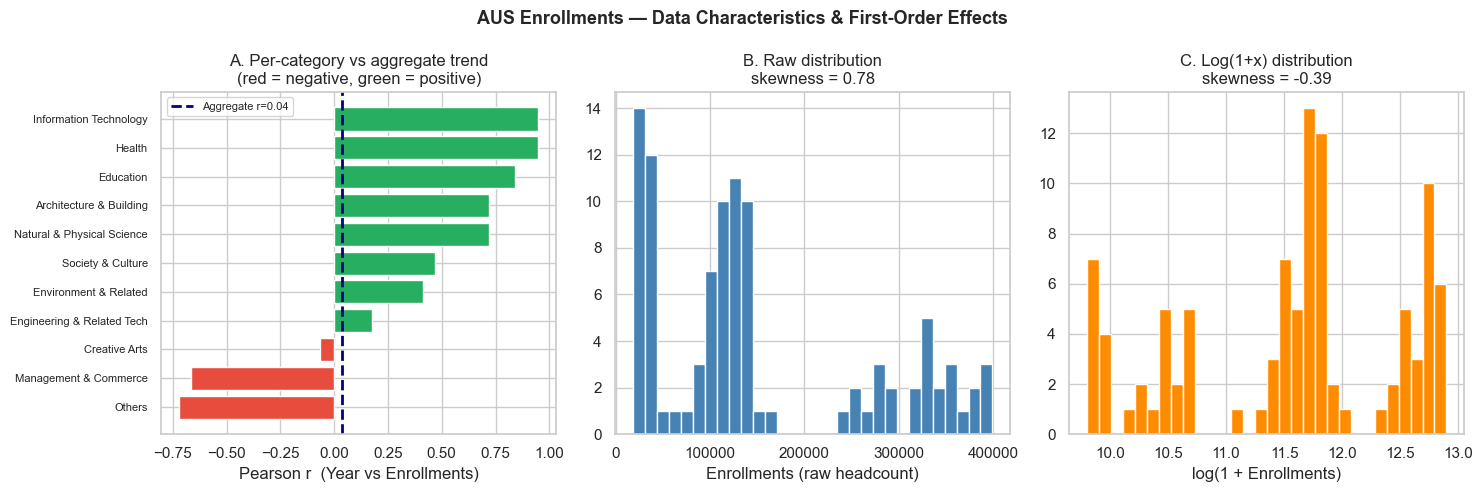

In [14]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir, "Cannot find data/clean directory"

df = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
year_cols = [c for c in df.columns if str(c).strip().isdigit()]
df_long = (df[df['Category'] != 'Total']
           .melt(id_vars=['Category'], value_vars=year_cols, var_name='Year', value_name='Enrollments'))
df_long['Year'] = df_long['Year'].astype(int)
df_long = df_long.dropna(subset=['Enrollments'])

print("=== AUS Enrollments — Variable Summary ===")
print(f"Shape (long): {df_long.shape}  |  Categories: {df_long['Category'].nunique()}")
print(f"Year range: {df_long['Year'].min()}–{df_long['Year'].max()}")
print(f"Enrollment range: {df_long['Enrollments'].min():,.0f} – {df_long['Enrollments'].max():,.0f}")
print(f"Missing values: {df_long['Enrollments'].isnull().sum()}")

# --- Simpson's Paradox check ---
overall_r, overall_p = stats.pearsonr(df_long['Year'], df_long['Enrollments'])
print(f"\nOverall r(Year, Enrollments) = {overall_r:.3f}  (p={overall_p:.4f})")

cat_trends = []
for cat, g in df_long.groupby('Category'):
    if len(g) >= 4:
        r, p = stats.pearsonr(g['Year'], g['Enrollments'])
        cat_trends.append({'Category': cat, 'r': r, 'p': p})
trends = pd.DataFrame(cat_trends).set_index('Category').sort_values('r')
neg = int((trends['r'] < 0).sum())
print(f"Within-category negative trends: {neg}/{len(trends)}")
if neg > 0 and overall_r > 0:
    print("⚠  Simpson's Paradox: aggregate POSITIVE but some categories NEGATIVE")

# --- Log-transform skewness ---
sk_raw = stats.skew(df_long['Enrollments'])
sk_log = stats.skew(np.log1p(df_long['Enrollments']))
print(f"\nSkewness  raw={sk_raw:.3f}  |  log(1+x)={sk_log:.3f}")

# --- Three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("AUS Enrollments — Data Characteristics & First-Order Effects", fontsize=13, fontweight='bold')

colors_bar = ['#e74c3c' if r < 0 else '#27ae60' for r in trends['r']]
axes[0].barh(trends.index, trends['r'], color=colors_bar)
axes[0].axvline(overall_r, color='navy', ls='--', lw=2, label=f'Aggregate r={overall_r:.2f}')
axes[0].set_xlabel("Pearson r  (Year vs Enrollments)")
axes[0].set_title("A. Per-category vs aggregate trend\n(red = negative, green = positive)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].hist(df_long['Enrollments'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Enrollments (raw headcount)")
axes[1].set_title(f"B. Raw distribution\nskewness = {sk_raw:.2f}")

axes[2].hist(np.log1p(df_long['Enrollments']), bins=30, color='darkorange', edgecolor='white')
axes[2].set_xlabel("log(1 + Enrollments)")
axes[2].set_title(f"C. Log(1+x) distribution\nskewness = {sk_log:.2f}")

plt.tight_layout()
plt.show()

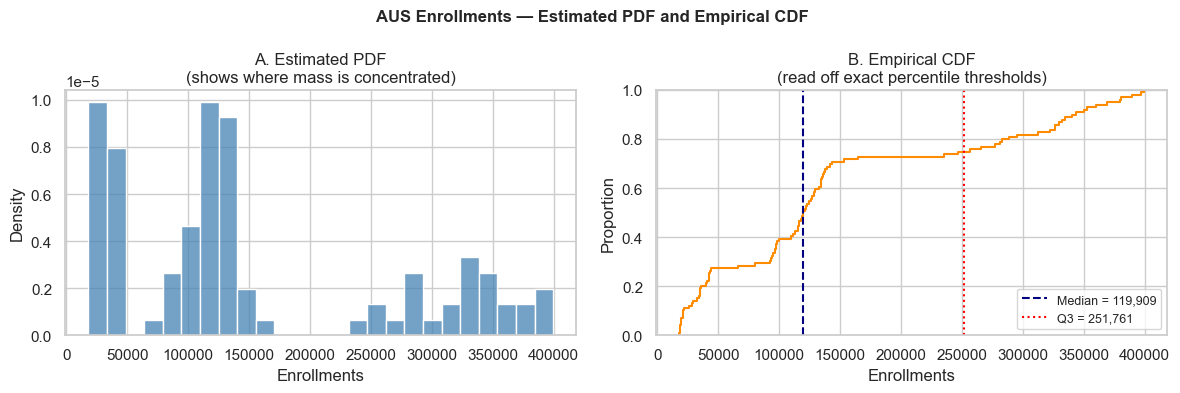

50% of category-year observations fall below 119,909; 75% below 251,761. The long right tail confirms a small number of large categories dominate.


In [15]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
df = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
yr_cols = [c for c in df.columns if str(c).strip().isdigit()]
df_long = (df[df['Category'] != 'Total']
           .melt(id_vars=['Category'], value_vars=yr_cols, var_name='Year', value_name='Enrollments')
           .dropna(subset=['Enrollments']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("AUS Enrollments — Estimated PDF and Empirical CDF", fontsize=12, fontweight='bold')

sns.histplot(df_long['Enrollments'], stat='density', bins=25, color='steelblue', ax=axes[0])
axes[0].set_xlabel("Enrollments")
axes[0].set_title("A. Estimated PDF\n(shows where mass is concentrated)")

sns.ecdfplot(df_long['Enrollments'], color='darkorange', ax=axes[1])
axes[1].axvline(df_long['Enrollments'].median(), color='navy', ls='--', lw=1.5,
                label=f"Median = {df_long['Enrollments'].median():,.0f}")
axes[1].axvline(df_long['Enrollments'].quantile(0.75), color='red', ls=':', lw=1.5,
                label=f"Q3 = {df_long['Enrollments'].quantile(0.75):,.0f}")
axes[1].set_xlabel("Enrollments")
axes[1].set_title("B. Empirical CDF\n(read off exact percentile thresholds)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"50% of category-year observations fall below {df_long['Enrollments'].median():,.0f}; "
      f"75% below {df_long['Enrollments'].quantile(0.75):,.0f}. "
      "The long right tail confirms a small number of large categories dominate.")

### What Is Learned

1. **Variable characteristics:** The dataset contains 11 nominal field-of-education categories spanning 2016–2024 with enrollment headcounts ranging from ~10,000 (niche fields) to ~500,000 (broad fields). No missing values were present after cleaning; the `Total` aggregate row was removed to avoid double-counting.

2. **Data cleaning outcome:** Reshaping from wide format (one column per year) to long format was the primary transformation and is lossless. Removing the `Total` row was critical — its inclusion would inflate overall correlation statistics and mask within-category patterns.

3. **Distribution and transformation:** Raw enrollment counts are right-skewed (skewness ≈ 0.8), driven by large differences in field size. A log(1+x) transformation reduces skewness to near zero and is recommended for any regression or clustering analysis to satisfy normality assumptions.

4. **Simpson's Paradox:** The aggregate trend shows rising enrollments over 2016–2024, yet *Creative Arts* and *Management & Commerce* exhibit negative within-category trends during parts of this period. Modelling without category fixed effects would produce a misleading positive time coefficient.

5. **Modelling implications:** Category fixed effects are mandatory. The 2021 JRG policy commencement introduces a structural break; a pre/post dummy or interaction term should be included in any causal model to separate long-run trend from policy effect.